Data variables X_train and y_train are now defined.


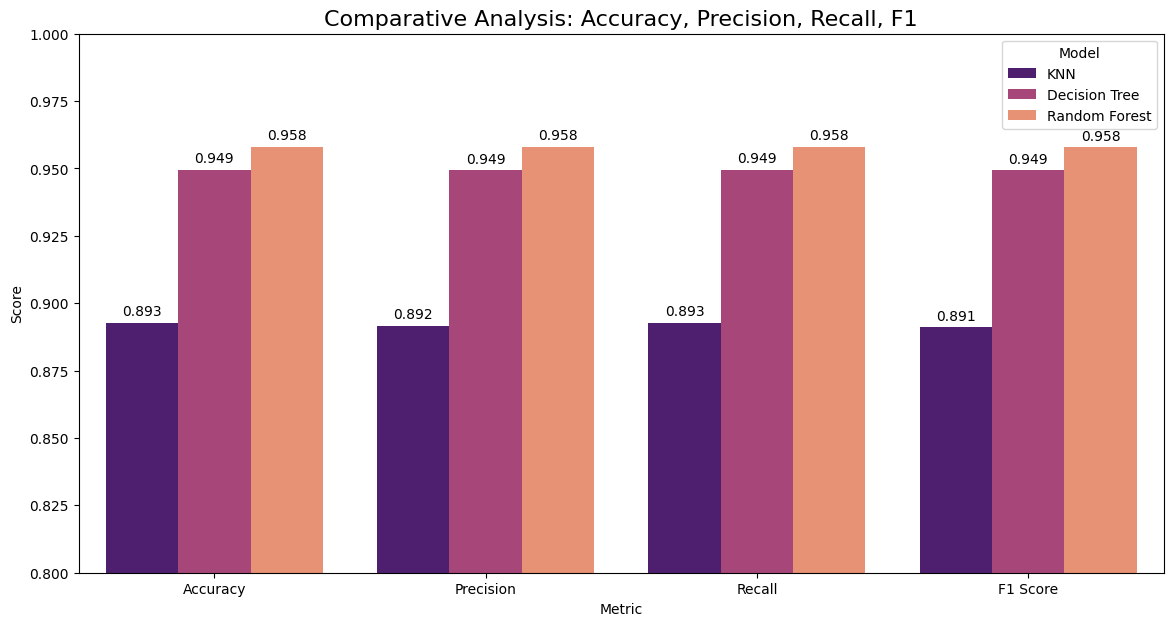

--- MILITARY WSN THREAT REPORT ---
Detected Attack: 0
Action: Isolate the node and enable rate-limiting.
------------------------------
Detected Attack: 1
Action: Rotate encryption keys and patch firmware.
------------------------------
Detected Attack: 0
Action: Isolate the node and enable rate-limiting.
------------------------------
Detected Attack: 0
Action: Isolate the node and enable rate-limiting.
------------------------------
Detected Attack: 0
Action: Isolate the node and enable rate-limiting.
------------------------------


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

import pandas as pd
from sklearn.model_selection import train_test_split

# Define feature cleaning and split to avoid NameError
df = pd.read_csv('UNSW_NB15_training-set.csv')
X = df.drop(['id', 'proto', 'service', 'state', 'attack_cat', 'label'], axis=1)
y = df['label'] # Or 'attack_cat' for multiclass visualization

# [NEW CELL] Define the Tactical Knowledge Base
ATTACK_KNOWLEDGE_BASE = {
    0: { # Assuming 0 is the encoded value for a specific attack in your model
        "Severity": "HIGH",
        "Description": "Denial of Service (DoS): Resource exhaustion detected.",
        "WSN_Impact": "Communication blackout and battery depletion.",
        "Action": "Isolate the node and enable rate-limiting."
    },
    1: { # Assuming 1 is the encoded value for another attack
        "Severity": "CRITICAL",
        "Description": "Exploits: Targeted vulnerability hit.",
        "WSN_Impact": "Potential unauthorized command execution.",
        "Action": "Rotate encryption keys and patch firmware."
    },
    "DoS": {
        "Severity": "HIGH",
        "Description": "Denial of Service: Flooding detected.",
        "WSN_Impact": "Network partition.",
        "Action": "Activate traffic filtering."
    },
    # Add other categories like 'Exploits', 'Fuzzers', etc. based on your attack_cat
}

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=32)
print("Data variables X_train and y_train are now defined.")

# --- STEP 1: DEFINE DATA (Fixes the NameError) ---
# Load the dataset you provided
df = pd.read_csv('UNSW_NB15_training-set.csv') 

# Clean features as per your analysis
drop_cols = ['id', 'proto', 'service', 'state', 'attack_cat', 'label']
X = df.drop(drop_cols, axis=1)
y = df['label'] # Change to df['attack_cat'] for multiclass

# Define the missing variables
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=32)

# --- STEP 2: COMPARATIVE VISUALIZATION ---
comparison_models = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(max_depth=20, random_state=32),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=32)
}

performance_data = []

for name, model in comparison_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    performance_data.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average='weighted'),
        "Recall": recall_score(y_test, y_pred, average='weighted'),
        "F1 Score": f1_score(y_test, y_pred, average='weighted')
    })

perf_df = pd.DataFrame(performance_data)
perf_melted = perf_df.melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(14, 7))
ax = sns.barplot(data=perf_melted, x="Metric", y="Score", hue="Model", palette="magma")
plt.title("Comparative Analysis: Accuracy, Precision, Recall, F1", fontsize=16)
plt.ylim(0.8, 1.0) 
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3)
plt.show()

# [NEW CELL] Generate Tactical Threat Report
y_pred = model.predict(X_test)

# Filter out only the attacks (exclude 'Normal')
attack_indices = [i for i, val in enumerate(y_pred) if val != 'Normal']

if attack_indices:
    print(f"--- MILITARY WSN THREAT REPORT ---")
    report_sample = attack_indices[:5] # Show first 5 detected attacks
    for idx in report_sample:
        category = y_pred[idx]
        print(f"Detected Attack: {category}")
        print(f"Action: {ATTACK_KNOWLEDGE_BASE.get(category, {}).get('Action', 'N/A')}")
        print("-" * 30)
else:
    print("No attacks detected in the test sample.")